In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator

c:\Users\Atul.Mangla\Desktop\Learning_LangGraph\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [15]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

## UPSC Aspirant Essay writing evaluation Workflow

We will get an essay text and we will evaluate the essay on 3 basis:

1. CoT - Clarity of Thought and score out of 10
2. DoA - Depth of Analysis and score out of 10
3. Language - Grammar, Vocabulary, and Style and score out of 10

Then we will give Final feedback and average score

In [4]:
class EvaluationSchema(BaseModel):
    score: int = Field(..., description="Score out of 10", ge=0, le=10)
    feedback: str = Field(..., description="Detailed feedback on the essay")

In [16]:
structured_model = llm.with_structured_output(EvaluationSchema)

In [6]:
class EssayState(TypedDict):
    essay: str
    Cot_feedbak: str
    DoA_feedback: str
    Language_feedback: str
    Overall_feedback: str
    # using a reducer function "add" to handle write conflicts for individual scores 
    # because we want to merge the scores from each branch to this variable
    individual_scores: Annotated[list[int], Field(description="List of scores for CoT, DoA, and Language"), operator.add]
    avg_score: float

In [13]:
def evaluate_language(state: EssayState) -> EssayState:
    
    prompt = f"""
    Evaluate the following essay for grammar, vocabulary, and style. 
    Provide a score out of 10 and detailed feedback.
    **Essay**:{state['essay']}
    """
    
    res = structured_model.invoke(prompt)
    
    return {'Language_feedback':res.feedback, 'individual_scores':[res.score]} 


def evaluate_CoT(state: EssayState) -> EssayState:
    
    prompt = f"""
    Evaluate the following essay for Chain-of-Thought reasoning. 
    Provide a score out of 10 and detailed feedback.
    **Essay**:{state['essay']}
    """
    
    res = structured_model.invoke(prompt)
    
    return {'CoT_feedback':res.feedback, 'individual_scores':[res.score]}   

def evaluate_DoA(state: EssayState) -> EssayState:
    
    prompt = f"""
    Evaluate the following essay for Depth-of-Analysis reasoning. 
    Provide a score out of 10 and detailed feedback.
    **Essay**:{state['essay']}
    """
    
    res = structured_model.invoke(prompt)
    
    return {'DoA_feedback':res.feedback, 'individual_scores':[res.score]}
    
    
def final_feedback(state: EssayState) -> EssayState:
    
    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])
    
    prompt = f"""
    The essay has been evaluated on three parameters: CoT(clarity of thoughts), DoA(depth of analysis), and Language(grammatical accuracy). 
    The scores are {state['individual_scores']} out of 10 respectively. 
    Provide an overall feedback for the essay.
    """
    
    res = llm.invoke(prompt)
    
    return {'Overall_feedback':res.content, 'avg_score':avg_score}

In [8]:
graph = StateGraph(EssayState)

graph.add_node('evaluate_language',evaluate_language)
graph.add_node('evaluate_CoT',evaluate_CoT)
graph.add_node('evaluate_DoA',evaluate_DoA)
graph.add_node('final_feedback',final_feedback)

graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_CoT')
graph.add_edge(START, 'evaluate_DoA')
graph.add_edge('evaluate_language', 'final_feedback')
graph.add_edge('evaluate_CoT', 'final_feedback')
graph.add_edge('evaluate_DoA', 'final_feedback')
graph.add_edge('final_feedback', END)

workflow=graph.compile()

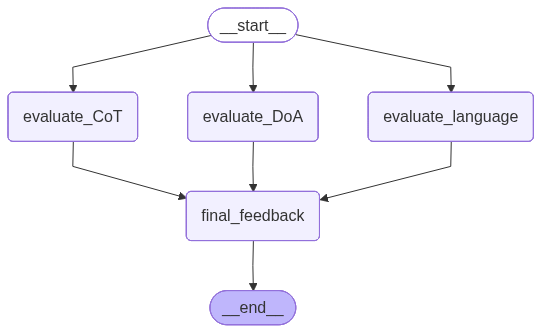

In [9]:
workflow

In [10]:
essay="""
The Silent Revolution: The Meteoric Rise of AI
For decades, Artificial Intelligence was a concept confined to the pages of science fiction and the quiet corridors of academic laboratories. We experienced "Narrow AI" in small, almost invisible ways: a Netflix recommendation, a spam filter, or a credit card fraud alert. However, the last few years have witnessed a "Cambrian Explosion" in machine intelligence, moving AI from the background of our lives to the very center of the global stage.
The Perfect Storm
The current rise of AI was not an accident; it was the result of a "perfect storm" of three converging forces: Massive Data, Exponential Compute, and Architectural Breakthroughs. The advent of the Transformer model in 2017 acted as the ultimate catalyst, allowing machines to understand context and language with human-like nuance. Suddenly, AI wasn't just processing numbers; it was understanding us.
From Generation to Agency
We are currently living through the second great wave of this rise. The first wave was Generative AI—the era of wonder where we realized machines could paint, write poetry, and code. It democratized creativity, allowing anyone with a prompt to become an artist or a programmer.
But as the novelty of generation settles, we are entering the era of Agentic AI. This is the shift from intelligence as a service to intelligence as a partner. We are no longer impressed by an AI that can simply describe a plan; we are building AI that can execute it. This transition marks the rise of the "Action-Oriented" machine—systems that can navigate the web, manage software, and solve multi-step problems autonomously.
The Human-AI Symbiosis
The rise of AI is often framed as a story of replacement, but the reality is becoming one of augmentation. As AI agents take over the "drudgery" of repetitive digital tasks—booking meetings, sorting data, and managing workflows—they clear the path for humans to focus on high-level strategy, ethics, and emotional intelligence.
Conclusion
The rise of AI is not a destination, but a journey toward a more efficient world. As we move from chatbots to autonomous agents, the boundary between "tool" and "teammate" continues to blur. The challenge of this new era is not just to build smarter machines, but to build them with the guardrails and transparency necessary to ensure that as AI rises, it lifts human potential along with it.
"""

In [24]:
input_state={'essay':essay}

output_state=workflow.invoke(input_state)

print(output_state['individual_scores'])
print(output_state['Overall_feedback'])

[9, 9, 9]
content="Based on the evaluation scores, it is clear that the essay has excelled in all three parameters: Clarity of Thoughts (CoT), Depth of Analysis (DoA), and Language (grammatical accuracy). \n\nThe scores of 9 out of 10 in each category suggest that the essay effectively conveys its ideas in a clear and concise manner, provides a thorough and nuanced analysis of the topic, and demonstrates strong grammatical accuracy with minimal errors.\n\nOverall, the essay demonstrates a high level of proficiency in all aspects of writing. The writer's ability to clearly articulate their thoughts, delve deeply into the topic, and express themselves with precision and accuracy is commendable.\n\nTo further improve, the writer could focus on refining their arguments, providing even more nuanced insights, and experimenting with more sophisticated language structures to elevate their writing to the next level. However, overall, this is an outstanding piece of writing that showcases the wr